<a href="https://www.kaggle.com/code/lalit7881/florida-real-estate-sold-dataset-2026?scriptVersionId=308328904" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/kanchana1990/florida-real-estate-sold-dataset-2026/florida_real_estate_sold_properties_ultimate.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/kanchana1990/florida-real-estate-sold-dataset-2026/florida_real_estate_sold_properties_ultimate.csv")

In [3]:
df.head()

,type,sub_type,listPrice,lastSoldPrice,sqft,stories,beds,baths,baths_full,baths_full_calc,garage,year_built,zip,sanitized_text
0,single_family,NaN,630000.0,605000,2274.0,1.0,2.0,3.0,2.0,2.0,2.0,2007.0,33446.0,"Beautiful 2 Bedroom + Den, 2.5 Bath Home - Mov..."
1,single_family,NaN,289000.0,285000,2170.0,1.0,3.0,2.0,2.0,2.0,2.0,1980.0,33876.0,Welcome to Florida living at its best! This 3-...
2,condos,condo,449000.0,425000,1722.0,NaN,3.0,2.0,2.0,2.0,2.0,2016.0,33913.0,Best Value in Casella and priced to sell... St...
3,single_family,NaN,599000.0,596000,1699.0,1.0,3.0,3.0,3.0,3.0,NaN,1952.0,33009.0,"Beautifully renovated 3-bedroom, 3-bathroom ho..."
4,single_family,NaN,173500.0,165000,640.0,1.0,1.0,1.0,1.0,1.0,NaN,1971.0,32118.0,Experience the ultimate beachfront lifestyle i...


In [4]:
df.tail()

,type,sub_type,listPrice,lastSoldPrice,sqft,stories,beds,baths,baths_full,baths_full_calc,garage,year_built,zip,sanitized_text
10888,condos,condo,169999.0,165000,1082.0,NaN,2.0,2.0,2.0,2.0,NaN,1965.0,33904.0,Direct Gulf Access Resort Lifestyle Just open ...
10889,condos,condo,579000.0,540000,1250.0,1.0,2.0,2.0,2.0,2.0,NaN,1999.0,33708.0,Enjoy the best of intercoastal living at Madei...
10890,townhomes,townhouse,309900.0,305000,1806.0,2.0,3.0,3.0,2.0,2.0,1.0,2006.0,32712.0,"This 3-bedroom, 2.5-bath end-unit townhome off..."
10891,townhomes,townhouse,639000.0,585000,1770.0,NaN,3.0,3.0,3.0,3.0,2.0,2011.0,33024.0,Welcome to Cooper City's highly sought-after g...
10892,townhomes,townhouse,960000.0,930000,2606.0,4.0,3.0,3.0,2.0,2.0,1.0,2017.0,33060.0,Rare 4-story marina-front townhome with ocean ...


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10893 entries, 0 to 10892
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   type             10893 non-null  object 
 1   sub_type         2476 non-null   object 
 2   listPrice        10881 non-null  float64
 3   lastSoldPrice    10893 non-null  int64  
 4   sqft             10136 non-null  float64
 5   stories          9161 non-null   float64
 6   beds             10217 non-null  float64
 7   baths            10254 non-null  float64
 8   baths_full       10210 non-null  float64
 9   baths_full_calc  10210 non-null  float64
 10  garage           7306 non-null   float64
 11  year_built       10215 non-null  float64
 12  zip              10891 non-null  float64
 13  sanitized_text   10865 non-null  object 
dtypes: float64(10), int64(1), object(3)
memory usage: 1.2+ MB


In [6]:
df.describe()

,listPrice,lastSoldPrice,sqft,stories,beds,baths,baths_full,baths_full_calc,garage,year_built,zip
count,1.088100e+04,1.089300e+04,10136.000000,9161.000000,10217.000000,10254.000000,10210.000000,10210.000000,7306.000000,10215.000000,10891.000000
mean,5.863834e+05,5.579736e+05,1850.802289,1.308154,3.069981,2.443827,2.230362,2.230362,1.943471,1996.975624,33468.624093
std,1.272724e+06,1.144589e+06,922.388909,0.585215,1.021450,0.980903,0.793634,0.793634,0.686992,23.384010,822.937076
min,9.500000e+02,1.000000e+01,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1700.000000,32003.000000
25%,2.649000e+05,2.550000e+05,1306.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1980.000000,32778.000000
50%,3.750000e+05,3.650000e+05,1675.500000,1.000000,3.000000,2.000000,2.000000,2.000000,2.000000,1999.000000,33547.000000
75%,5.790000e+05,5.575000e+05,2182.000000,2.000000,4.000000,3.000000,2.000000,2.000000,2.000000,2020.000000,34119.000000
max,5.990000e+07,5.166718e+07,24829.000000,6.000000,20.000000,20.000000,20.000000,20.000000,16.000000,2027.000000,34997.000000


In [7]:
df.isnull().sum()

type                  0
sub_type           8417
listPrice            12
lastSoldPrice         0
sqft                757
stories            1732
beds                676
baths               639
baths_full          683
baths_full_calc     683
garage             3587
year_built          678
zip                   2
sanitized_text       28
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(21)

In [9]:
df.columns

Index(['type', 'sub_type', 'listPrice', 'lastSoldPrice', 'sqft', 'stories',
       'beds', 'baths', 'baths_full', 'baths_full_calc', 'garage',
       'year_built', 'zip', 'sanitized_text'],
      dtype='object')

In [10]:
df.dtypes

type                object
sub_type            object
listPrice          float64
lastSoldPrice        int64
sqft               float64
stories            float64
beds               float64
baths              float64
baths_full         float64
baths_full_calc    float64
garage             float64
year_built         float64
zip                float64
sanitized_text      object
dtype: object

In [11]:
df.shape

(10893, 14)

In [12]:
df.nunique()

type                   8
sub_type               2
listPrice           2748
lastSoldPrice       2640
sqft                2745
stories                6
beds                  13
baths                 14
baths_full            11
baths_full_calc       11
garage                10
year_built           122
zip                  867
sanitized_text     10615
dtype: int64

## EDA

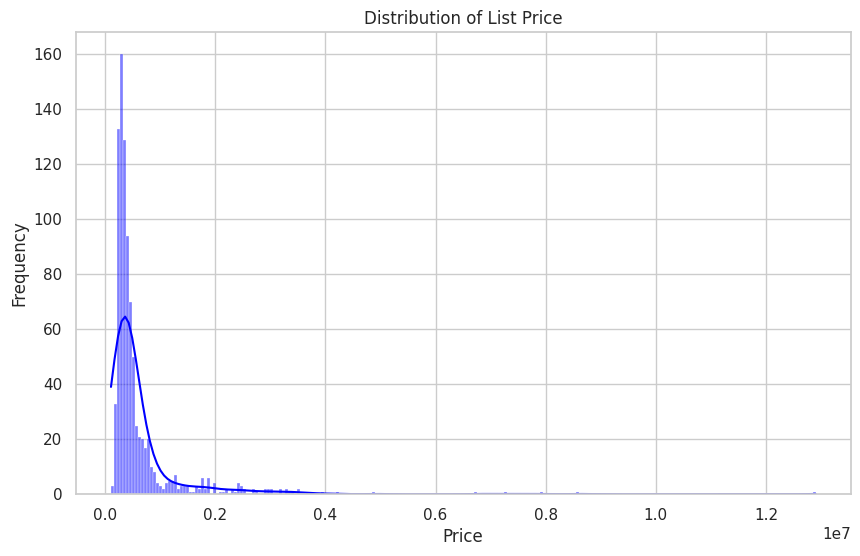

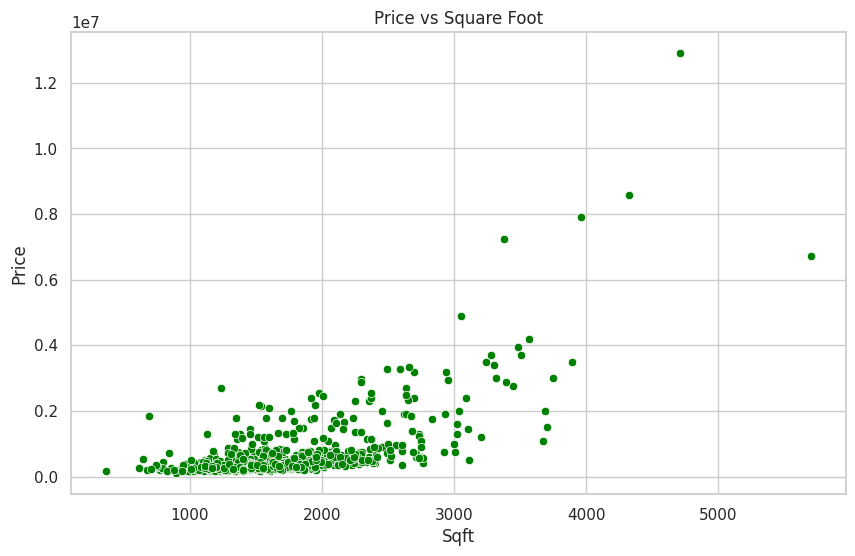

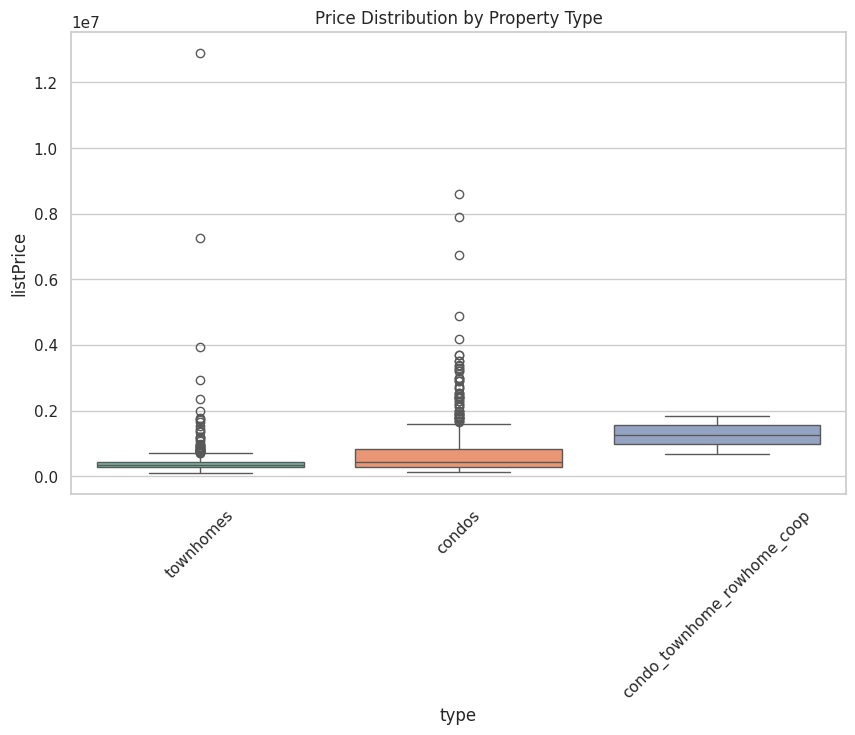

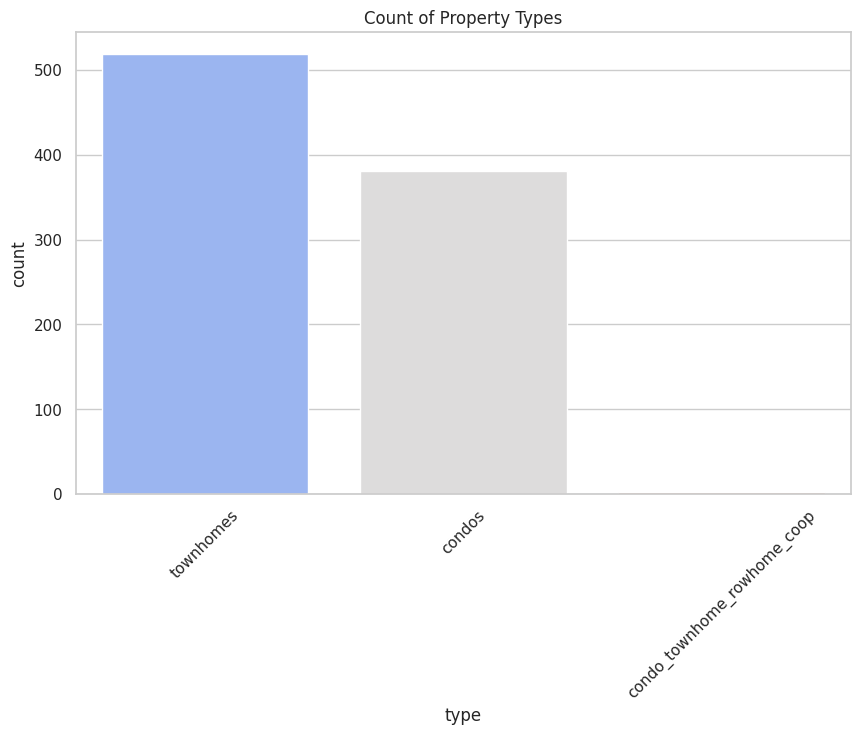

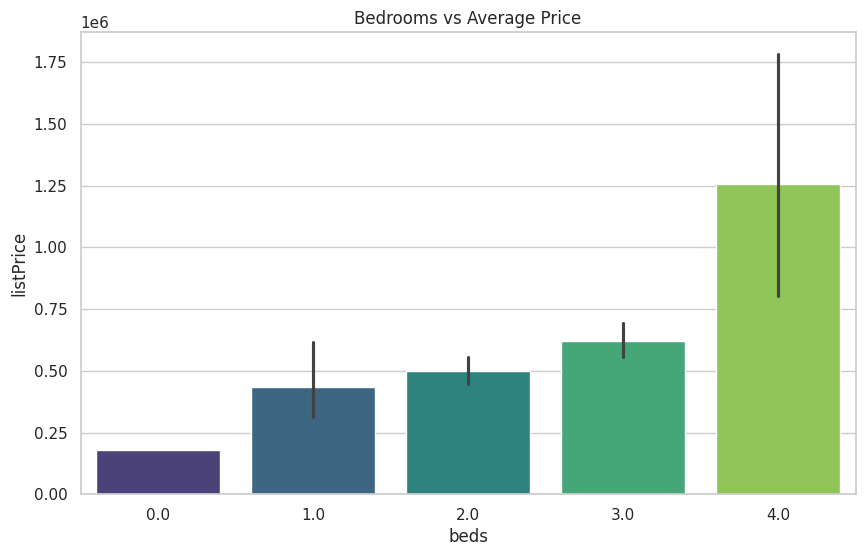

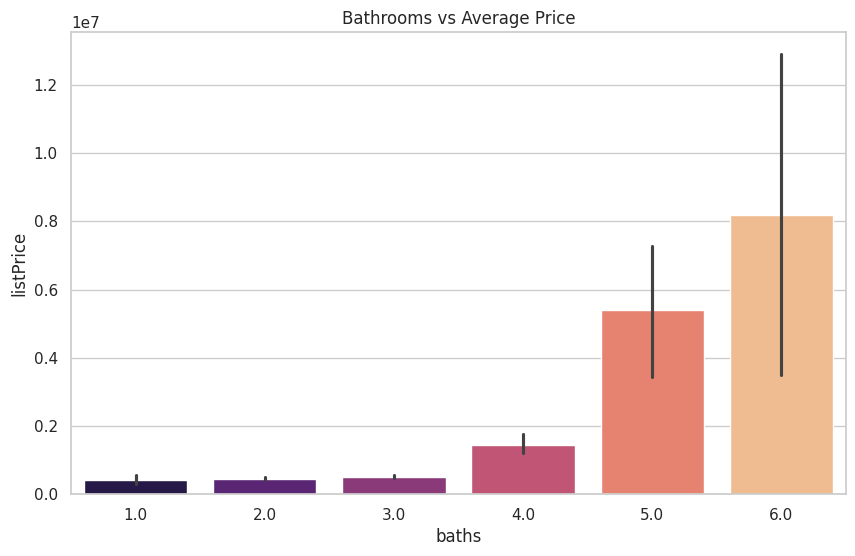

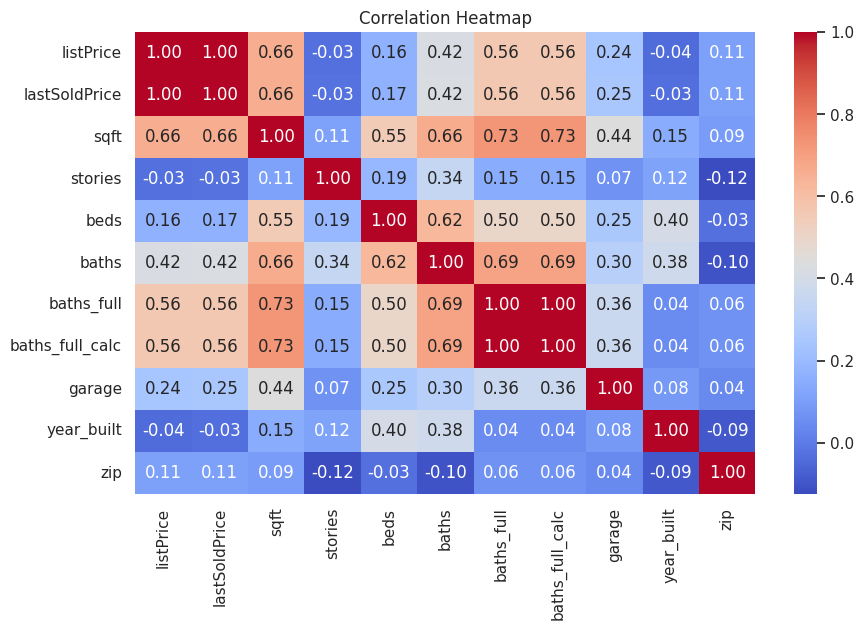

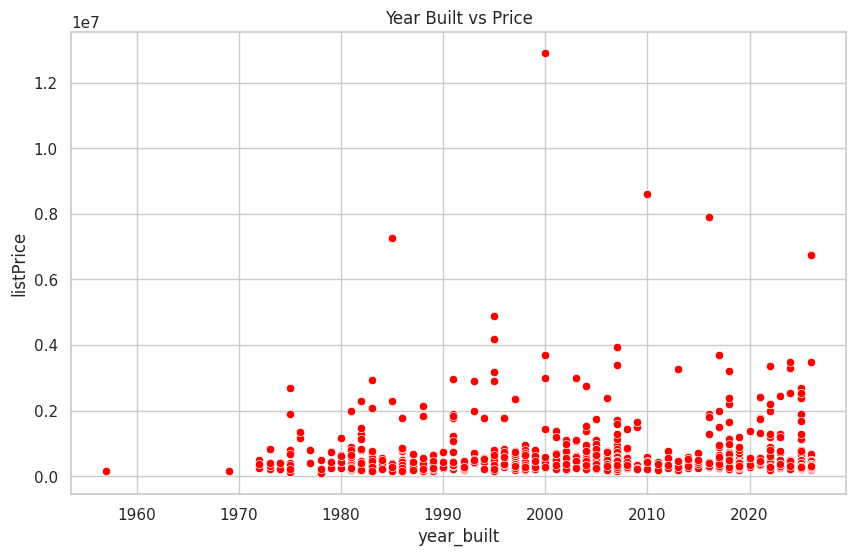

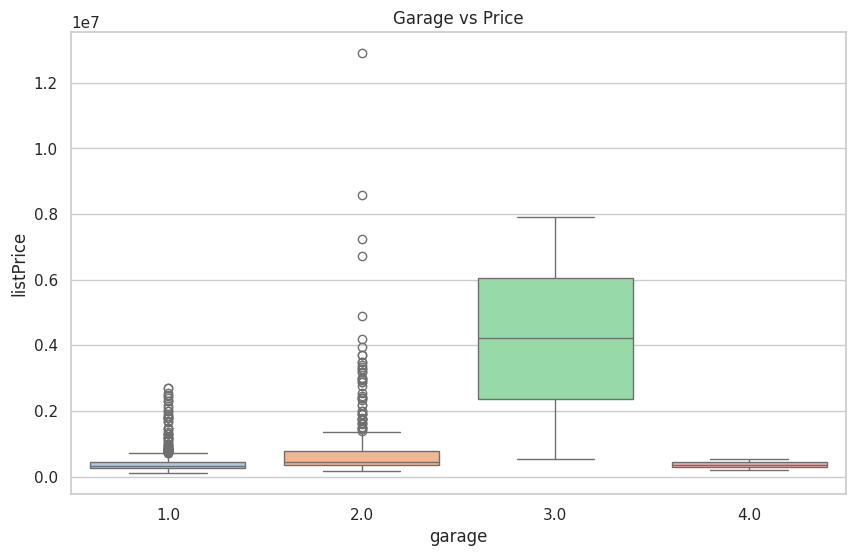

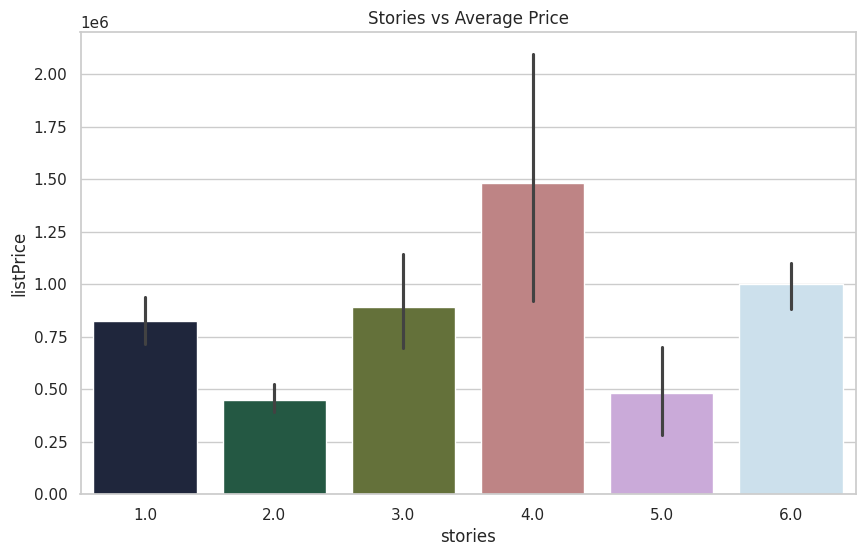

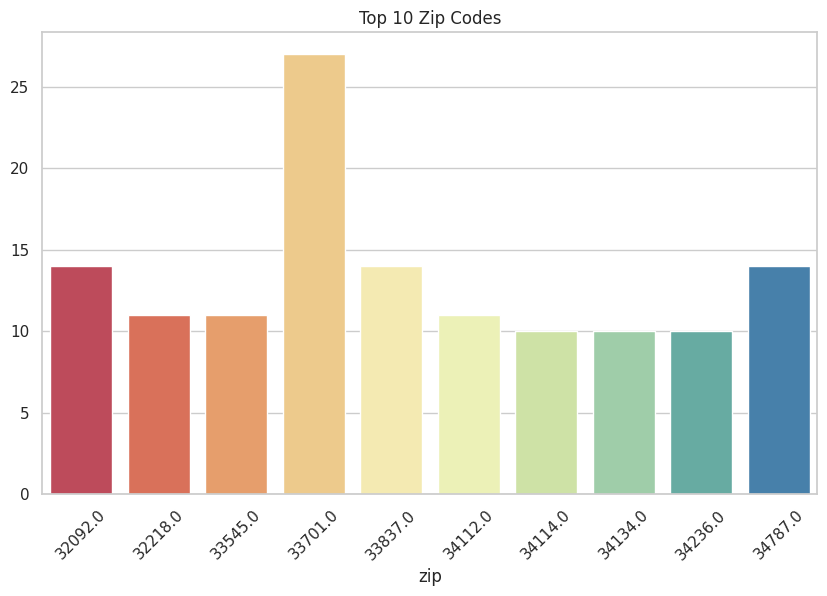

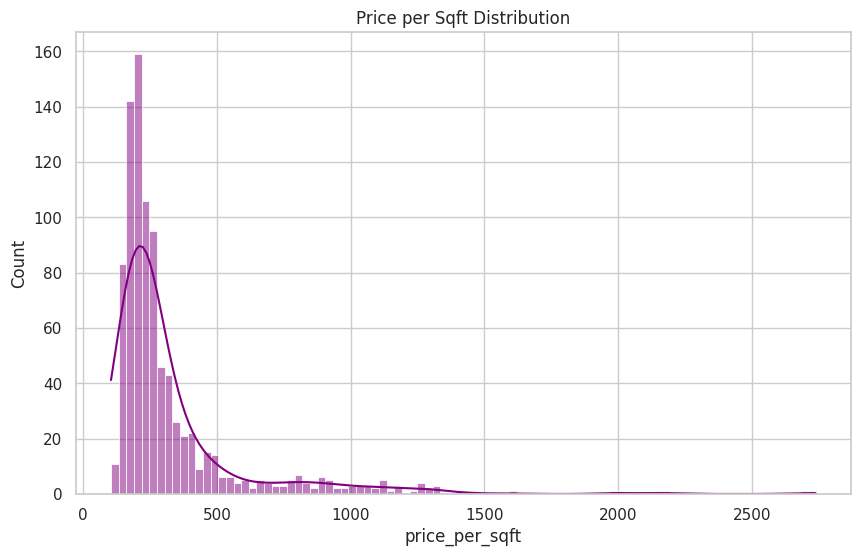

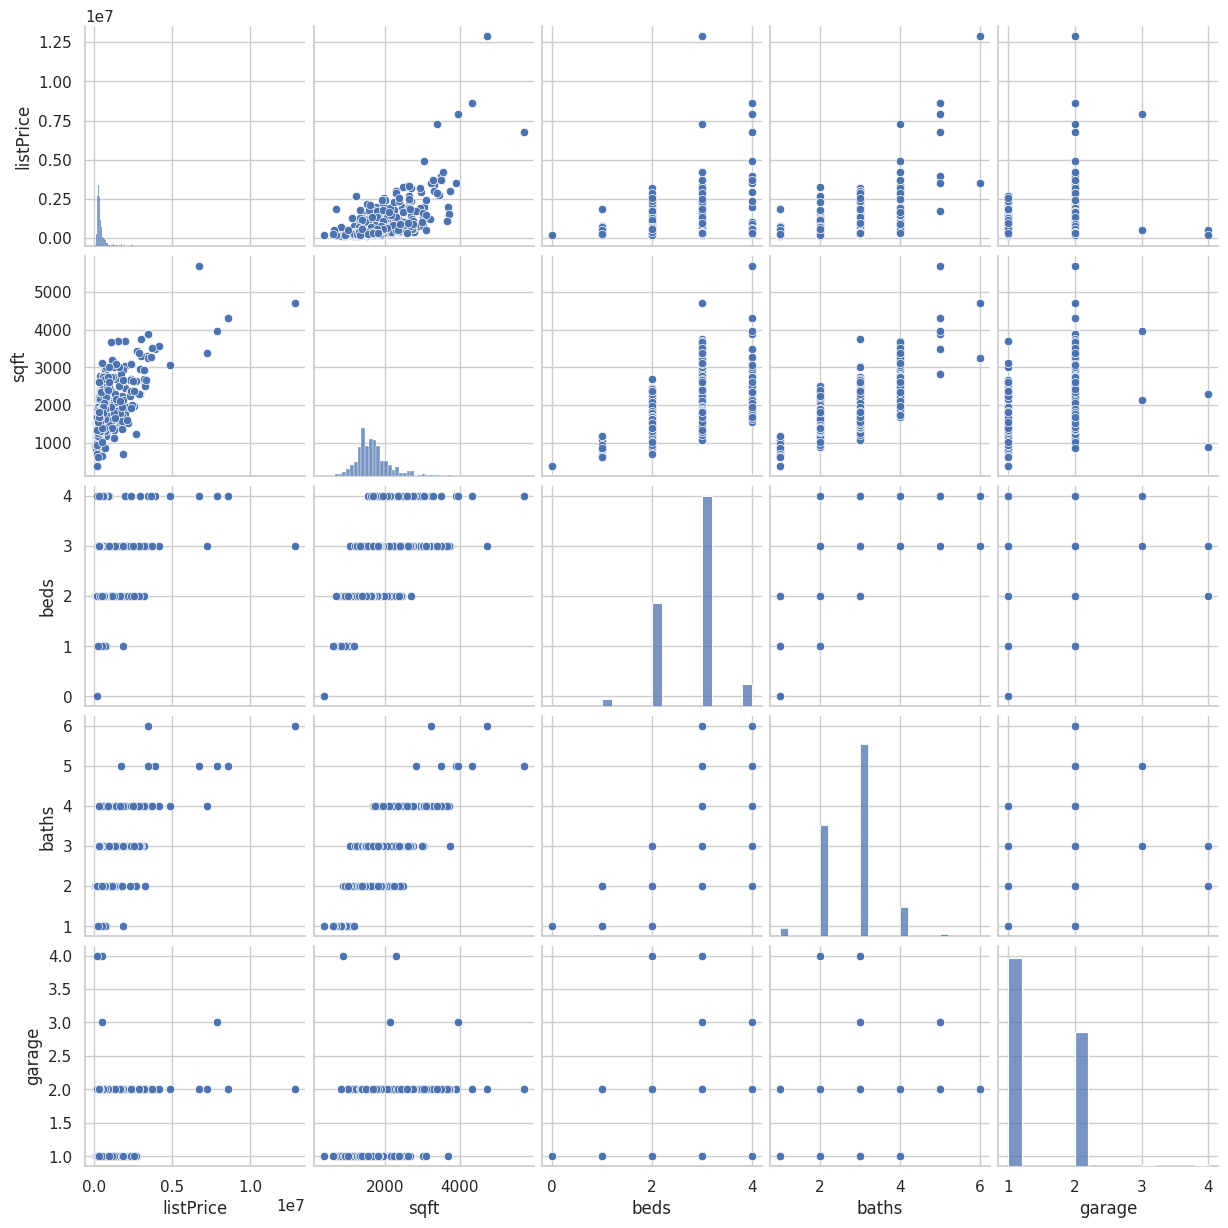

In [13]:

# Basic cleaning
df = df.drop_duplicates()
df = df.dropna()

# -----------------------------
# Set Style
# -----------------------------
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10,6)

# -----------------------------
# 1. Distribution of Prices
# -----------------------------
plt.figure()
sns.histplot(df['listPrice'], kde=True, color='blue')
plt.title("Distribution of List Price")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

# -----------------------------
# 2. Price vs Square Feet
# -----------------------------
plt.figure()
sns.scatterplot(x='sqft', y='listPrice', data=df, color='green')
plt.title("Price vs Square Foot")
plt.xlabel("Sqft")
plt.ylabel("Price")
plt.show()

# -----------------------------
# 3. Boxplot of Price by Property Type
# -----------------------------
plt.figure()
sns.boxplot(x='type', y='listPrice', data=df, palette='Set2')
plt.title("Price Distribution by Property Type")
plt.xticks(rotation=45)
plt.show()

# -----------------------------
# 4. Count of Property Types
# -----------------------------
plt.figure()
sns.countplot(x='type', data=df, palette='coolwarm')
plt.title("Count of Property Types")
plt.xticks(rotation=45)
plt.show()

# -----------------------------
# 5. Bedrooms vs Price
# -----------------------------
plt.figure()
sns.barplot(x='beds', y='listPrice', data=df, palette='viridis')
plt.title("Bedrooms vs Average Price")
plt.show()

# -----------------------------
# 6. Bathrooms vs Price
# -----------------------------
plt.figure()
sns.barplot(x='baths', y='listPrice', data=df, palette='magma')
plt.title("Bathrooms vs Average Price")
plt.show()

# -----------------------------
# 7. Correlation Heatmap
# -----------------------------
plt.figure()
num_cols = df.select_dtypes(include=np.number)
corr = num_cols.corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# -----------------------------
# 8. Year Built vs Price
# -----------------------------
plt.figure()
sns.scatterplot(x='year_built', y='listPrice', data=df, color='red')
plt.title("Year Built vs Price")
plt.show()

# -----------------------------
# 9. Garage vs Price
# -----------------------------
plt.figure()
sns.boxplot(x='garage', y='listPrice', data=df, palette='pastel')
plt.title("Garage vs Price")
plt.show()

# -----------------------------
# 10. Stories vs Price
# -----------------------------
plt.figure()
sns.barplot(x='stories', y='listPrice', data=df, palette='cubehelix')
plt.title("Stories vs Average Price")
plt.show()

# -----------------------------
# 11. Zip Code Distribution
# -----------------------------
plt.figure()
top_zip = df['zip'].value_counts().head(10)
sns.barplot(x=top_zip.index, y=top_zip.values, palette='Spectral')
plt.title("Top 10 Zip Codes")
plt.xticks(rotation=45)
plt.show()

# -----------------------------
# 12. Price per Sqft
# -----------------------------
df['price_per_sqft'] = df['listPrice'] / df['sqft']

plt.figure()
sns.histplot(df['price_per_sqft'], kde=True, color='purple')
plt.title("Price per Sqft Distribution")
plt.show()

# -----------------------------
# 13. Pairplot (Important)
# -----------------------------
sns.pairplot(df[['listPrice','sqft','beds','baths','garage']], palette='husl')
plt.show()

## Feature engineering


Logistic Regression
Accuracy: 0.9834254143646409
              precision    recall  f1-score   support

           0       0.97      1.00      0.98        91
           1       1.00      0.97      0.98        90

    accuracy                           0.98       181
   macro avg       0.98      0.98      0.98       181
weighted avg       0.98      0.98      0.98       181


Random Forest
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        91
           1       1.00      1.00      1.00        90

    accuracy                           1.00       181
   macro avg       1.00      1.00      1.00       181
weighted avg       1.00      1.00      1.00       181


Gradient Boosting
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        91
           1       1.00      1.00      1.00        90

    accuracy                           1.00       181
   macro avg    

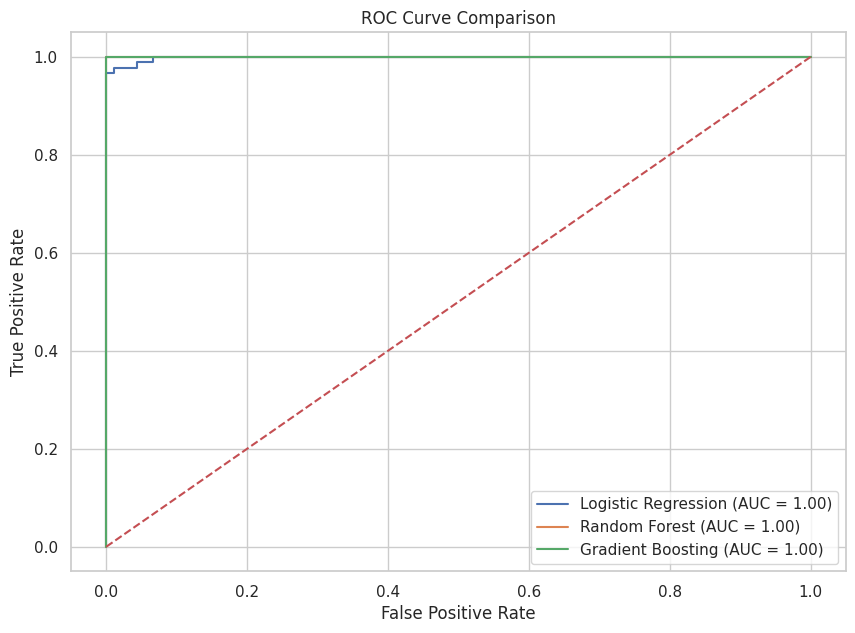

In [14]:
# ===============================
# 1. IMPORT LIBRARIES
# ===============================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier


# ===============================
# 3. BASIC CLEANING
# ===============================
df = df.drop_duplicates()
df = df.dropna()

# ===============================
# 4. TARGET CREATION (Classification)
# ===============================
threshold = df['listPrice'].median()
df['price_category'] = (df['listPrice'] > threshold).astype(int)

# ===============================
# 5. FEATURE ENGINEERING
# ===============================
df['house_age'] = 2026 - df['year_built']
df['price_per_sqft'] = df['listPrice'] / df['sqft']

# ===============================
# 6. FEATURES & TARGET
# ===============================
X = df.drop(columns=['price_category', 'sanitized_text'])
y = df['price_category']

# ===============================
# 7. TRAIN-TEST SPLIT (NO LEAKAGE)
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ===============================
# 8. ENCODING (SAFE - NO ERROR)
# ===============================
cat_cols = ['type', 'sub_type', 'zip']

encoder = OrdinalEncoder(
    handle_unknown='use_encoded_value',
    unknown_value=-1
)

# Fit ONLY on training data
X_train[cat_cols] = encoder.fit_transform(X_train[cat_cols])

# Transform test data
X_test[cat_cols] = encoder.transform(X_test[cat_cols])

# ===============================
# 9. SCALING (ONLY TRAIN FIT)
# ===============================
num_cols = X_train.select_dtypes(include=np.number).columns

scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

# ===============================
# 10. MODELS
# ===============================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=150, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier()
}

# ===============================
# 11. TRAIN + EVALUATE
# ===============================
plt.figure(figsize=(10,7))

for name, model in models.items():
    
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    
    print(f"\n{name}")
    print("Accuracy:", acc)
    print(classification_report(y_test, y_pred))
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

# ===============================
# 12. FINAL ROC CURVE
# ===============================
plt.plot([0,1], [0,1], linestyle='--')  # baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

## Thank you...pls upvote!!!!